# Modèle A — Comparaison de 5 modèles (étapes A.3 / A.4)

**Question** : quel algorithme estime le mieux le prix d'un véhicule d'occasion au Maroc ?

**Protocole** — identique pour tous les modèles (`ml/src/model_a/features.py`, `compare.py`) :

| Élément | Choix | Justification |
|---|---|---|
| Données | 70 368 annonces MUCars-2024 nettoyées (étape A.2) | |
| Découpage | 70 % entraînement / 15 % validation / 15 % test, stratifié sur les déciles de prix, graine 42 | Chaque jeu couvre toute la gamme de prix. Pas de découpage temporel : toutes les annonces datent de 2024 sans date précise |
| Cible | log(prix), reconverti en DH pour les mesures | Une erreur de 10 000 DH n'a pas le même poids à 40 000 DH qu'à 600 000 DH |
| Variables | 30 : marque, modèle, âge, kilométrage, boîte, carburant, puissance, état, origine, 1ʳᵉ main, ville, équipements… | |
| Catégories rares | < 20 annonces dans le train → « autre » (appris sur le train seul) | Évite la fuite d'information vers validation / test |
| Paramètres | Valeurs raisonnables par défaut, **sans réglage** | Comparaison équitable ; seul le gagnant est réglé ensuite |
| Évaluation | Jeu de **validation** | Le jeu de test reste intact pour le score final |

**Mesures** : MAE (erreur moyenne en DH), erreur médiane, MAPE (erreur moyenne en %), R², part des annonces estimées à ±15 % près.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ML_DIR / "reports" / "figures"
comparaison = json.loads((ML_DIR / "reports" / "model_a_comparison.json").read_text(encoding="utf-8"))

print("Tailles :", comparaison["tailles"])
tableau = pd.DataFrame(comparaison["resultats"]).set_index("modele")
colonnes = {"MAE_DH": "MAE (DH)", "erreur_mediane_DH": "Erreur médiane (DH)", "MAPE_pct": "MAPE (%)", "R2": "R²",
            "part_a_moins_de_15pct": "À ±15 % (%)", "duree_entrainement_s": "Entraînement (s)"}
tableau[list(colonnes)].rename(columns=colonnes).round({"MAE (DH)": 0, "Erreur médiane (DH)": 0, "MAPE (%)": 1, "R²": 3, "À ±15 % (%)": 1, "Entraînement (s)": 1})

Tailles : {'train': 49257, 'validation': 10555, 'test': 10556}


,MAE (DH),Erreur médiane (DH),MAPE (%),R²,À ±15 % (%),Entraînement (s)
modele,,,,,,
XGBoost,13446.0,6542.0,11.0,0.903,79.1,62.8
CatBoost,15321.0,7616.0,11.8,0.891,75.5,256.2
Random Forest,16433.0,7519.0,12.7,0.863,74.3,22.6
Régression linéaire,21690.0,10119.0,16.1,0.799,65.1,1.8
Médiane par groupe,24287.0,9004.0,19.6,0.705,66.0,0.1


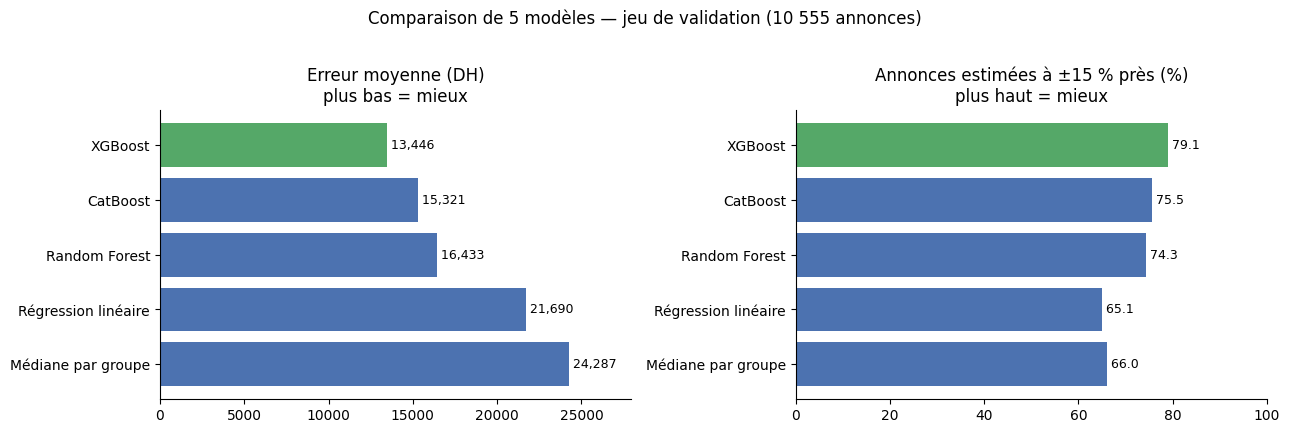

In [2]:
meilleur = comparaison["meilleur"]
t = tableau.iloc[::-1]
couleurs = ["#55A868" if n == meilleur else "#4C72B0" for n in t.index]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, titre, fmt in [
    (axes[0], "MAE_DH", "Erreur moyenne (DH)\nplus bas = mieux", "{:,.0f}"),
    (axes[1], "part_a_moins_de_15pct", "Annonces estimées à ±15 % près (%)\nplus haut = mieux", "{:.1f}"),
]:
    ax.barh(t.index, t[col], color=couleurs)
    for y, v in enumerate(t[col]):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=9)
    ax.set_title(titre)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_xlim(0, t["MAE_DH"].max() * 1.15)
axes[1].set_xlim(0, 100)
fig.suptitle("Comparaison de 5 modèles — jeu de validation (10 555 annonces)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "a4_comparaison.png", dpi=110, bbox_inches="tight"); plt.show()

In [3]:
reference = tableau.loc["Médiane par groupe", "MAE_DH"]
gain = (1 - tableau["MAE_DH"] / reference) * 100
gain.round(1).rename("Réduction de l'erreur vs médiane (%)").to_frame()

,Réduction de l'erreur vs médiane (%)
modele,
XGBoost,44.6
CatBoost,36.9
Random Forest,32.3
Régression linéaire,10.7
Médiane par groupe,0.0


## Analyse

- **XGBoost est le meilleur sur toutes les mesures** : erreur moyenne de ~13 400 DH, soit **45 % de moins** que l'estimation naïve (médiane des annonces comparables), et près de 8 annonces sur 10 estimées à ±15 % près.
- **Les modèles à base d'arbres dominent** (XGBoost, CatBoost, Random Forest) : le prix dépend de l'âge de façon non linéaire (forte décote les premières années) et d'interactions (une Mercedes ne perd pas sa valeur comme une Dacia), que les arbres capturent naturellement.
- **CatBoost, pourtant spécialisé dans les variables catégorielles** (318 modèles, 97 villes après regroupement), arrive 2ᵉ, et son entraînement est 4 fois plus long. L'hypothèse initiale selon laquelle il aurait l'avantage n'est pas confirmée avec ces paramètres par défaut.
- **La régression linéaire** fait à peine mieux que la médiane : elle ne peut représenter ni la courbe de décote, ni les interactions entre variables.
- Toutes les prédictions sont très rapides (< 0,1 ms par annonce) : le critère de temps n'est pas discriminant pour une utilisation dans l'app.

## Décision

**XGBoost est retenu.** Il est le seul à être réglé (Optuna, étape A.5) puis évalué une seule fois sur le jeu de test (étape A.6).

*Limite du protocole : chaque modèle est comparé avec des paramètres par défaut raisonnables ; un réglage de chacun pourrait réduire les écarts, mais l'avance d'XGBoost (−12 % d'erreur vs le 2ᵉ) rend un changement de classement peu probable.*